In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
data = pd.read_csv("dataset/customer_sales_dataset.csv")

data.head()

,OrderID,Product,Category,Price,Quantity,TotalSales,Region,City,PaymentMethod,OrderDate
0,1,Office Desk,Furniture,285.45,4,1141.80,North,Kolkata,Cash on Delivery,2022-07-08
1,2,Running Shoes,Fashion,122.79,1,122.79,West,Bangalore,UPI,2022-06-25
2,3,Blender,Home,85.61,3,256.83,South,Kolkata,Debit Card,2023-06-01
3,4,Running Shoes,Fashion,109.07,3,327.21,North,Chennai,Cash on Delivery,2023-02-24
4,5,Blender,Home,90.16,3,270.48,West,Pune,Credit Card,2022-07-21


In [19]:
data.shape

(30000, 10)

In [20]:
data.columns

Index(['OrderID', 'Product', 'Category', 'Price', 'Quantity', 'TotalSales',
       'Region', 'City', 'PaymentMethod', 'OrderDate'],
      dtype='str')

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        30000 non-null  int64  
 1   Product        30000 non-null  str    
 2   Category       30000 non-null  str    
 3   Price          30000 non-null  float64
 4   Quantity       30000 non-null  int64  
 5   TotalSales     30000 non-null  float64
 6   Region         30000 non-null  str    
 7   City           30000 non-null  str    
 8   PaymentMethod  30000 non-null  str    
 9   OrderDate      30000 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 2.3 MB


In [22]:
data.isnull().sum()

OrderID          0
Product          0
Category         0
Price            0
Quantity         0
TotalSales       0
Region           0
City             0
PaymentMethod    0
OrderDate        0
dtype: int64

In [23]:
data["OrderDate"] = pd.to_datetime(data["OrderDate"])

In [24]:
region_sales = data.groupby("Region")["TotalSales"].sum()

region_sales

Region
East     4844283.14
North    4868000.72
South    4933909.77
West     4739369.36
Name: TotalSales, dtype: float64

In [26]:
top_products = data.groupby("Product")["TotalSales"].sum()

top_products

Product
Backpack          579791.35
Blender           746792.57
Desk Chair       1439165.84
Headphones       1118733.72
Laptop           6419235.79
Office Desk      2819251.76
Running Shoes    1033253.39
Smartphone       4802886.45
T-Shirt           236013.39
Water Bottle      190438.73
Name: TotalSales, dtype: float64

In [27]:
top_products = top_products.sort_values(ascending=False)

top_products.head()

Product
Laptop         6419235.79
Smartphone     4802886.45
Office Desk    2819251.76
Desk Chair     1439165.84
Headphones     1118733.72
Name: TotalSales, dtype: float64

In [29]:
category_sales = data.groupby("Category")["TotalSales"].sum()

category_sales

Category
Accessories      579791.35
Electronics    12340855.96
Fashion         1269266.78
Furniture       4258417.60
Home             937231.30
Name: TotalSales, dtype: float64

In [31]:
payment_sales = data.groupby("PaymentMethod")["TotalSales"].sum()

payment_sales

PaymentMethod
Cash on Delivery    3863007.76
Credit Card         3872607.50
Debit Card          3851776.02
Net Banking         3973145.75
UPI                 3825025.96
Name: TotalSales, dtype: float64

In [33]:
data["Month"] = data["OrderDate"].dt.month

In [34]:
monthly_sales = data.groupby("Month")["TotalSales"].sum()

monthly_sales

Month
1     2014293.99
2     1842929.19
3     1993019.93
4     1851986.50
5     2000528.73
6     1705071.26
7     1394697.94
8     1343968.80
9     1276144.18
10    1263759.66
11    1316359.91
12    1382802.90
Name: TotalSales, dtype: float64

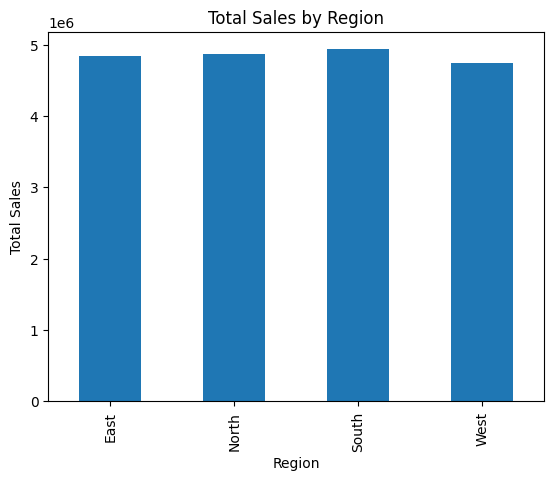

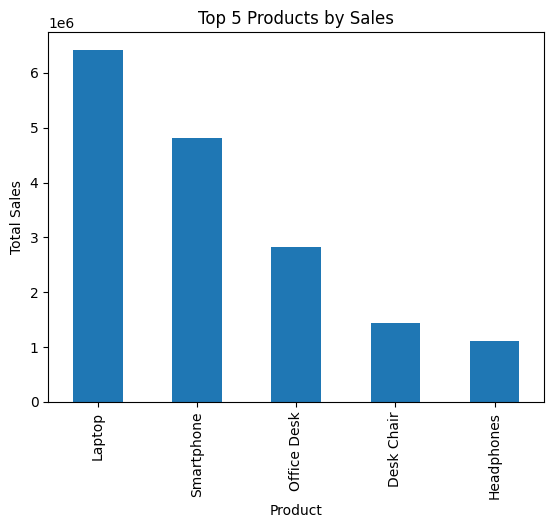

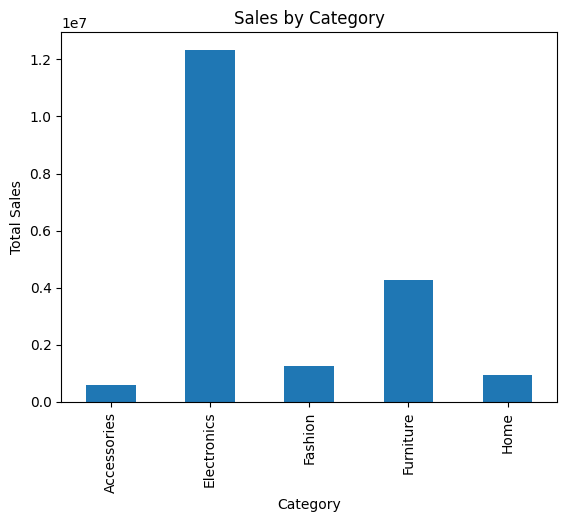

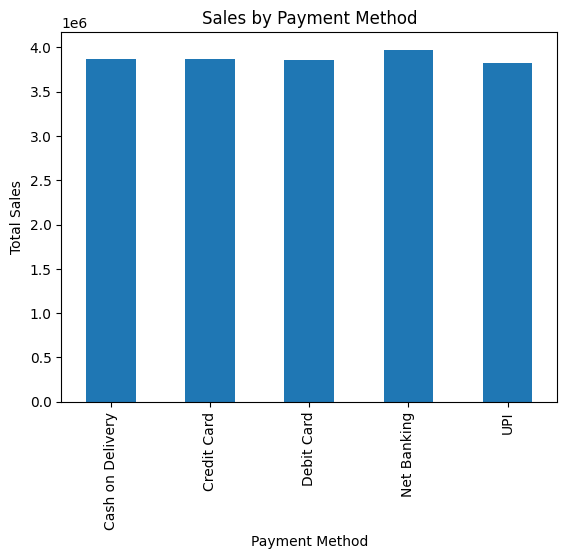

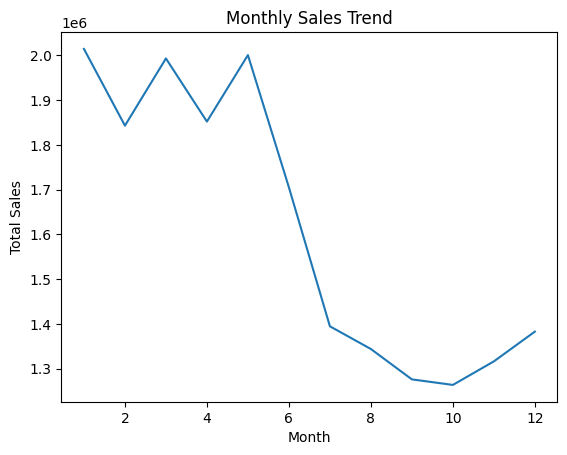

In [40]:
import os
import matplotlib.pyplot as plt

# create visuals folder if it does not exist
if not os.path.exists("visuals"):
    os.makedirs("visuals")

# 1 Regional Sales Chart
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.savefig("visuals/region_sales.png")
plt.show()


# 2 Top Products Chart
top_products.head().plot(kind="bar")
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.savefig("visuals/top_products.png")
plt.show()


# 3 Category Sales Chart
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.savefig("visuals/category_sales.png")
plt.show()


# 4 Payment Method Chart
payment_sales.plot(kind="bar")
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.savefig("visuals/payment_sales.png")
plt.show()


# 5 Monthly Sales Trend
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.savefig("visuals/monthly_sales.png")
plt.show()